# Análise Exploratória de Dados (EDA) :
---



Criem uma venv com o comando 'python -m venv venv'

Ativem a venv o comando 'venv/Scripts/activate'

Instalem as bibliotecas necessárias com o comando 'pip install -r requirements.txt'

### Os datasets são:
#### Ao escolher o dataset que você vai trabalhar, copie o path e cole na célula de abetura do arquivo para ter acesso ao dataframe.

*   **Titanic - Machine Learning from Disaster** — dados sobre os passageiros do Titanic (idade, sexo, classe, se sobreviveram etc.).
https://www.kaggle.com/datasets/yasserh/titanic-dataset
*   **Mushroom Classification** — características físicas de diferentes espécies de cogumelos (cor, formato, odor etc.) e se são venenosos ou comestíveis.
https://www.kaggle.com/datasets/uciml/mushroom-classification


*   **Car Price Prediction** — dados sobre carros usados à venda (marca, modelo, ano, quilometragem, preço etc.).
https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars





In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
# Usando Pandas para abrir o arquivo
# O dataset é baixado automaticamente aqui, então não é preciso ter nenhum CSV separado.
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url_titanic, sep=',')

# Traduzindo os nomes das colunas para português
df = df.rename(columns={
    'PassengerId': 'IdPassageiro',
    'Survived': 'Sobreviveu',
    'Pclass': 'Classe',
    'Name': 'Nome',
    'Sex': 'Sexo',
    'Age': 'Idade',
    'SibSp': 'Irmãos_Cônjuges',
    'Parch': 'Pais_Filhos',
    'Ticket': 'Bilhete',
    'Fare': 'Tarifa',
    'Cabin': 'Cabine',
    'Embarked': 'Embarque'
})

# Traduzindo os valores categóricos para português
df['Sexo'] = df['Sexo'].map({'male': 'Masculino', 'female': 'Feminino'})
df['Embarque'] = df['Embarque'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

df

,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmãos_Cônjuges,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
0,1,0,3,"Braund, Mr. Owen Harris",Masculino,22.0,1,0,A/5 21171,7.2500,NaN,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Feminino,38.0,1,0,PC 17599,71.2833,C85,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",Feminino,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Feminino,35.0,1,0,113803,53.1000,C123,Southampton
4,5,0,3,"Allen, Mr. William Henry",Masculino,35.0,0,0,373450,8.0500,NaN,Southampton
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",Masculino,27.0,0,0,211536,13.0000,NaN,Southampton
887,888,1,1,"Graham, Miss. Margaret Edith",Feminino,19.0,0,0,112053,30.0000,B42,Southampton
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Feminino,NaN,1,2,W./C. 6607,23.4500,NaN,Southampton
889,890,1,1,"Behr, Mr. Karl Howell",Masculino,26.0,0,0,111369,30.0000,C148,Cherbourg


### 💡 Antes de tudo, é importante realizar uma **análise estatística** para entender melhor a natureza dos dados:

### Inspeção inicial dos dados:

Tirem um tempo para pesquisar sobre as funções na documentação do Pandas!

**.head()**

**.tail()**

**.info()**:

**.describe()**

Essas funções são indispensáveis para conhecer o dataset e planejar os próximos passos da análise!


### Existem outras funções muito úteis também, principalmente quando se deseja **visualizar problemas** no dataset, são elas:
####Problemas esses que podem ser a ausência de informações, valores faltantes (NaN, NULL) ou dados inconsistentes.

**.value_counts()**

**.isnull()**

**isnull().sum()**

**.unique()**

**.isna()**

**.sum()**

 Sobre a função de cada uma, deixaremos para vocês explorarem por conta própria e aprenderem mais a fundo sobre. 🚀

In [7]:
# Inspeção inicial dos dados
print("### .head() ###")
display(df.head())

print("\n### .tail() ###")
display(df.tail())

print("\n### .info() ###")
df.info()

print("\n### .describe() ###")
display(df.describe())

print("\n### .value_counts() em colunas categóricas ###")
print("Sexo:\n", df['Sexo'].value_counts())
print("\nEmbarque:\n", df['Embarque'].value_counts())
print("\nClasse:\n", df['Classe'].value_counts())
print("\nSobreviveu:\n", df['Sobreviveu'].value_counts())

print("\n### .unique() em colunas-chave ###")
print("Embarque únicos:", df['Embarque'].unique())
print("Classe únicos:", df['Classe'].unique())

print("\n### .isnull() - retorna uma máscara booleana (True = valor ausente) ###")
display(df.isnull().head())

print("\n### .isnull().sum() - soma a máscara por coluna, contando os ausentes ###")
print(df.isnull().sum())

print("\n### .isna() - é sinônimo de .isnull(), mesmo resultado ###")
display(df.isna().head())
print("df.isnull().equals(df.isna()) ->", df.isnull().equals(df.isna()))

print("\n### .sum() - aplicado sobre isna(), soma tudo de novo (total geral de ausentes) ###")
print("Total geral de valores ausentes no dataset:", df.isna().sum().sum())

### .head() ###


,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmãos_Cônjuges,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
0,1,0,3,"Braund, Mr. Owen Harris",Masculino,22.0,1,0,A/5 21171,7.2500,NaN,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Feminino,38.0,1,0,PC 17599,71.2833,C85,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",Feminino,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Feminino,35.0,1,0,113803,53.1000,C123,Southampton
4,5,0,3,"Allen, Mr. William Henry",Masculino,35.0,0,0,373450,8.0500,NaN,Southampton



### .tail() ###


,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmãos_Cônjuges,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
886,887,0,2,"Montvila, Rev. Juozas",Masculino,27.0,0,0,211536,13.00,NaN,Southampton
887,888,1,1,"Graham, Miss. Margaret Edith",Feminino,19.0,0,0,112053,30.00,B42,Southampton
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Feminino,NaN,1,2,W./C. 6607,23.45,NaN,Southampton
889,890,1,1,"Behr, Mr. Karl Howell",Masculino,26.0,0,0,111369,30.00,C148,Cherbourg
890,891,0,3,"Dooley, Mr. Patrick",Masculino,32.0,0,0,370376,7.75,NaN,Queenstown



### .info() ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IdPassageiro     891 non-null    int64  
 1   Sobreviveu       891 non-null    int64  
 2   Classe           891 non-null    int64  
 3   Nome             891 non-null    object 
 4   Sexo             891 non-null    object 
 5   Idade            714 non-null    float64
 6   Irmãos_Cônjuges  891 non-null    int64  
 7   Pais_Filhos      891 non-null    int64  
 8   Bilhete          891 non-null    object 
 9   Tarifa           891 non-null    float64
 10  Cabine           204 non-null    object 
 11  Embarque         889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

### .describe() ###


...


### .value_counts() em colunas categóricas ###
Sexo:
 Sexo
Masculino    577
Feminino     314
Name: count, dtype: int64

Embarque:
 Embarque
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

Classe:
 Classe
3    491
1    216
2    184
Name: count, dtype: int64

Sobreviveu:
 Sobreviveu
0    549
1    342
Name: count, dtype: int64

### .unique() em colunas-chave ###
Embarque únicos: ['Southampton' 'Cherbourg' 'Queenstown' nan]
Classe únicos: [3 1 2]

### .isnull() - retorna uma máscara booleana (True = valor ausente) ###


,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmãos_Cônjuges,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False



### .isnull().sum() - soma a máscara por coluna, contando os ausentes ###
IdPassageiro         0
Sobreviveu           0
Classe               0
Nome                 0
Sexo                 0
Idade              177
Irmãos_Cônjuges      0
Pais_Filhos          0
Bilhete              0
Tarifa               0
Cabine             687
Embarque             2
dtype: int64

### .isna() - é sinônimo de .isnull(), mesmo resultado ###


,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmãos_Cônjuges,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


df.isnull().equals(df.isna()) -> True

### .sum() - aplicado sobre isna(), soma tudo de novo (total geral de ausentes) ###
Total geral de valores ausentes no dataset: 866


### Quando se fala de análise estatística, é inevitável não falarmos de **Boxplot**


Ele te ajuda a realizar um resumo estatístico visual dos dados, mostrando mediana, valor máximo e mínimo, distribuição dos dados, e, principalmente, os famosos **outliers**.

**Importante**: O boxplot complementa o uso do describe(). Enquanto o describe() fornece os valores exatos, o boxplot apresenta uma representação visual que facilita a interpretação. Ambos devem ser usados juntos para obter uma análise completa. 😎

**Faz toda diferença** se aprofundar para entender e interpretar os elementos do boxplot (mediana, quartis, outliers, e amplitude interquartil). Por isso, recomendamos procurarem sobre isso na internet. Aqui estão algumas sugestões:

[How to interpret a boxplot- Data analysis and visualization](https://en.fernandafperes.com.br/blog/boxplot-interpretation/)

[Interpreting box plots- video Khan Academy](https://www.khanacademy.org/math/cc-sixth-grade-math/cc-6th-data-statistics/cc-6th-box-whisker-plots/v/interpreting-box-plots)


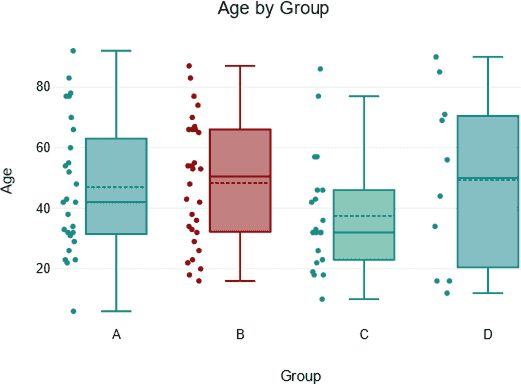

Para plotar o gráfico, use bibliotecas como: [matlotlib](https://matplotlib.org/stable/), [seaborn](https://seaborn.pydata.org/), [plotly](https://plotly.com/)

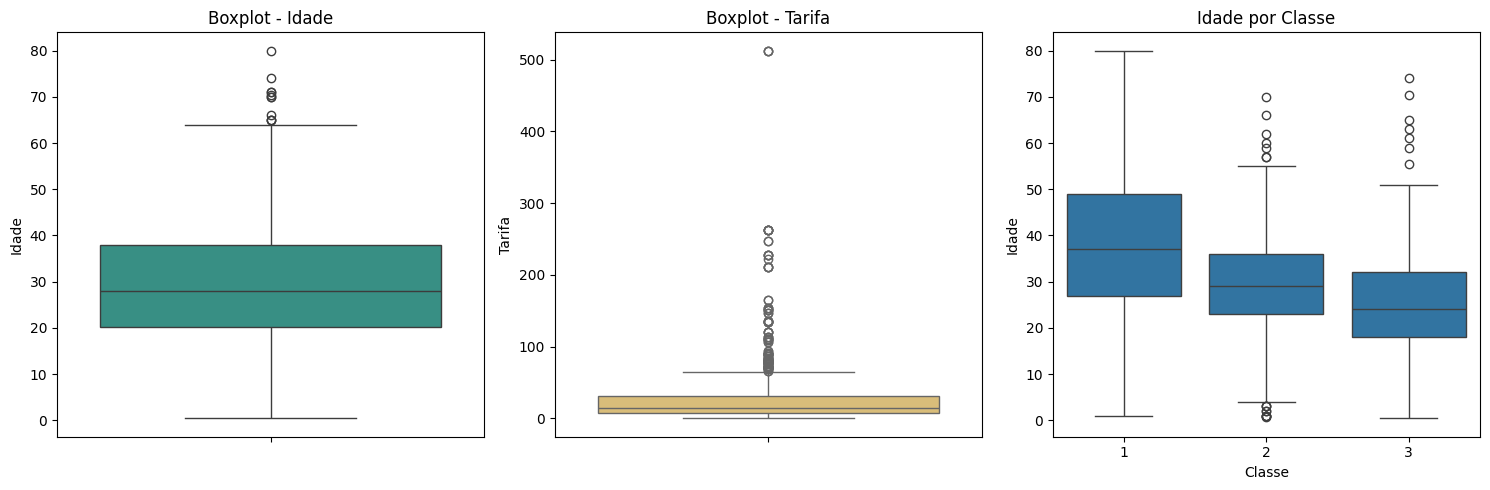

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots para identificar outliers nas variáveis numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['Idade'], ax=axes[0], color='#2a9d8f')
axes[0].set_title('Boxplot - Idade')
axes[0].set_ylabel('Idade')

sns.boxplot(y=df['Tarifa'], ax=axes[1], color='#e9c46a')
axes[1].set_title('Boxplot - Tarifa')
axes[1].set_ylabel('Tarifa')

sns.boxplot(x=df['Classe'], y=df['Idade'], ax=axes[2])
axes[2].set_title('Idade por Classe')
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('Idade')

plt.tight_layout()
plt.show()

# Tarifa apresenta outliers evidentes (passageiros que pagaram valores muito altos).
# Idade tem poucos outliers, com passageiros bem mais velhos que a maioria.

## 1.2 - Limpeza de dados

---



Agora que temos uma visão geral dos dados, é hora de limpá-los! Remova inconsistências, como dados ausentes e tipos incorretos, para garantir a qualidade da análise exploratória. Novamente, consulte a documentação do Pandas para ajudar nesse processo.

### Lembre-se que existem muitas funções ao seu favor! ✨

**dropna()**: Remove as linhas ou colunas com valores ausentes(nulos) ou irrelevantes para sua análise.

**fillna()**: Preenche os valores ausentes com algum valor específico, como a média, a mediana ou um valor constante, dependendo do contexto.

Essas funções são essenciais para garantir que seu dataset esteja limpo e pronto para análise! E o melhor é que existem muitas outras opções além dessas. Dêem uma olhada na documentação e descubram quais outras funções podem se adequar melhor à análise de vocês.

## 1.3 - Análise Exploratória dos Dados (EDA)

---



🔍 Após concluir a etapa de limpeza dos dados, agora é o momento de analisar mais a fundo o que está acontecendo no dataset.

O próximo passo é identificar correlações e examinar a distribuição das variáveis presentes. Para isso, recomenda-se o uso da biblioteca [matplotlib](https://matplotlib.org/) para criar gráficos que representem essas relações.

Plote quantos gráficos forem necessários, não tenha pena, apenas bom senso!!

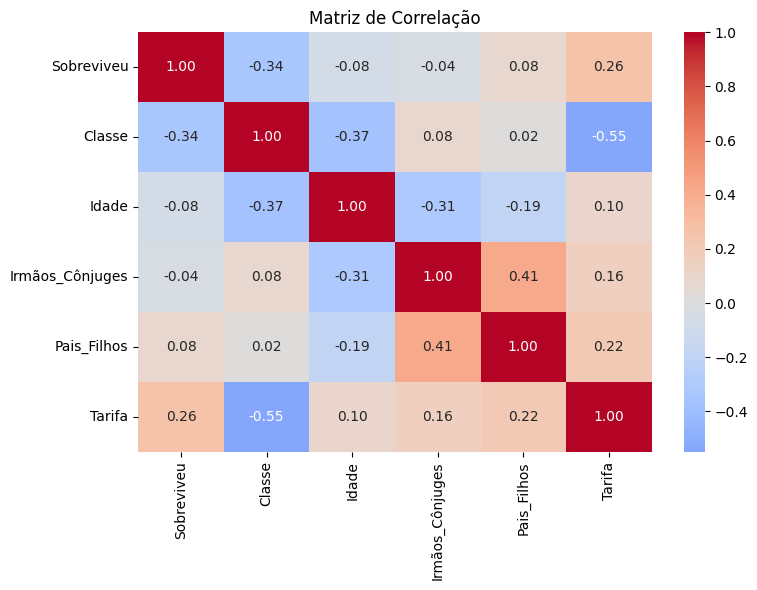

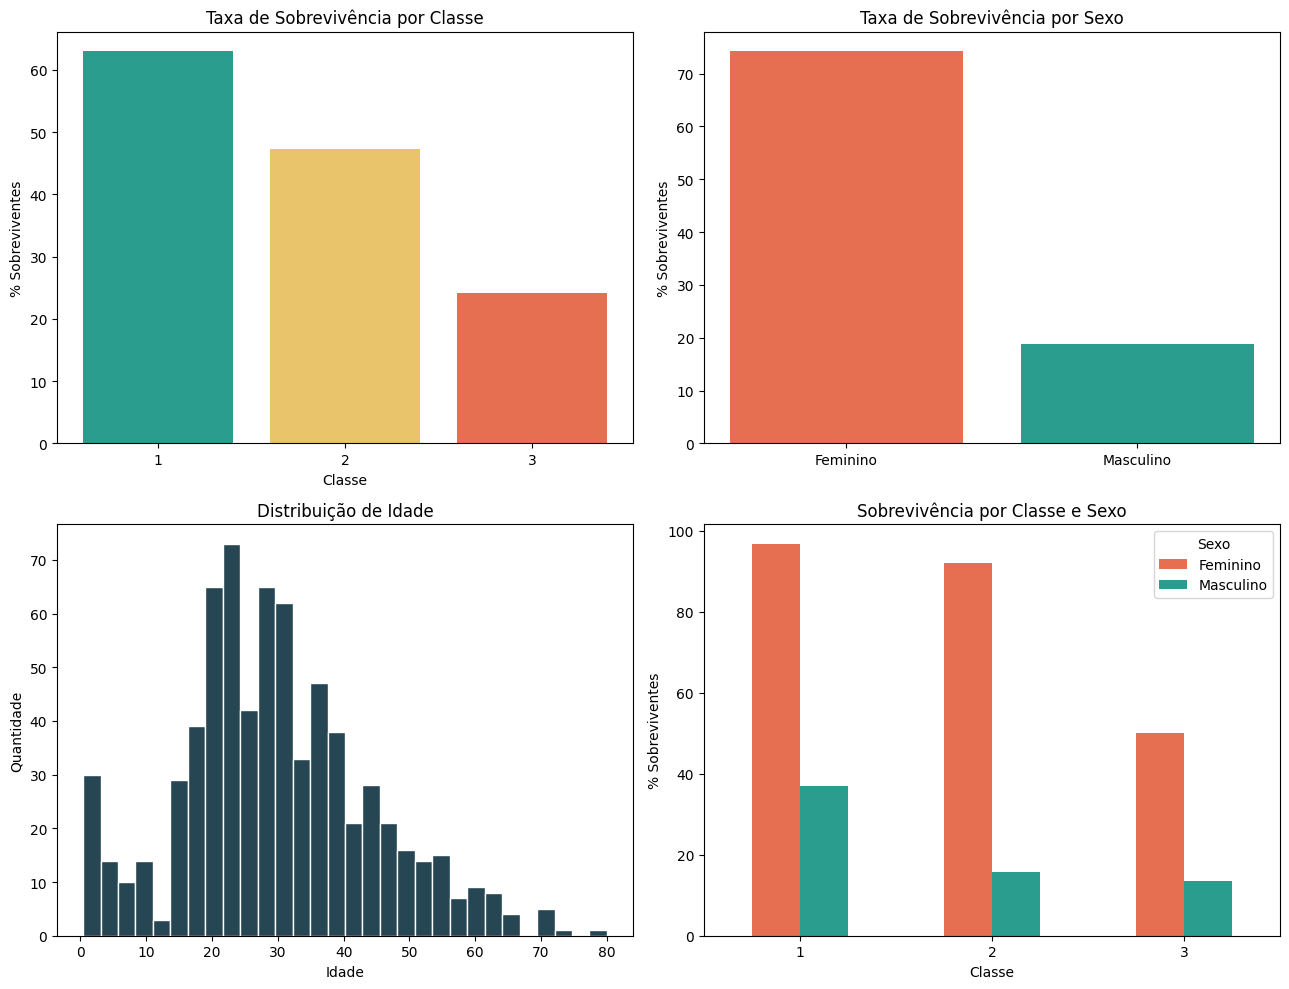

In [9]:
# Matriz de correlação
plt.figure(figsize=(8, 6))
col_numericas = ['Sobreviveu', 'Classe', 'Idade', 'Irmãos_Cônjuges', 'Pais_Filhos', 'Tarifa']
sns.heatmap(df[col_numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

# Distribuições e relações com a sobrevivência
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sobrev_classe = df.groupby('Classe')['Sobreviveu'].mean() * 100
axes[0,0].bar(sobrev_classe.index.astype(str), sobrev_classe.values, color=['#2a9d8f','#e9c46a','#e76f51'])
axes[0,0].set_title('Taxa de Sobrevivência por Classe')
axes[0,0].set_xlabel('Classe')
axes[0,0].set_ylabel('% Sobreviventes')

sobrev_sexo = df.groupby('Sexo')['Sobreviveu'].mean() * 100
axes[0,1].bar(sobrev_sexo.index, sobrev_sexo.values, color=['#e76f51','#2a9d8f'])
axes[0,1].set_title('Taxa de Sobrevivência por Sexo')
axes[0,1].set_ylabel('% Sobreviventes')

axes[1,0].hist(df['Idade'], bins=30, color='#264653', edgecolor='white')
axes[1,0].set_title('Distribuição de Idade')
axes[1,0].set_xlabel('Idade')
axes[1,0].set_ylabel('Quantidade')

pivot = df.pivot_table(index='Classe', columns='Sexo', values='Sobreviveu', aggfunc='mean') * 100
pivot.plot(kind='bar', ax=axes[1,1], color=['#e76f51','#2a9d8f'])
axes[1,1].set_title('Sobrevivência por Classe e Sexo')
axes[1,1].set_xlabel('Classe')
axes[1,1].set_ylabel('% Sobreviventes')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# A correlação mais forte com Sobreviveu é Classe (negativa) e Tarifa (positiva).
# Mulheres e passageiros de 1ª classe tiveram taxas de sobrevivência muito maiores.

## 1.4 - Feature engineering e dados categóricos

---



### 1.4.1 - Sempre que falamos de Data Science, lembramos dos diferentes tipos de dados. E, junto deles, surgem os temidos dados categóricos!

Esses dados são bem diferentes das variáveis numéricas, então a gente precisa dar uma atenção extra pra trabalhar com eles de forma eficaz. Bora transformar alguns deles usando os métodos que já vimos, como o **OneHotEncoder**! 🔥

Depois disso, vamos mergulhar no **Feature Engineering**!
Essa técnica é super poderosa e serve para extrair informações mais relevantes dos dados que já temos. Ela consiste em selecionar, manipular e transformar colunas e linhas do dataset, dando um novo significado ou enriquecendo as informações. Um exemplo clássico é a criação de uma coluna de IMC (Índice de Massa Corporal) a partir das colunas de altura e peso.

Agora é sua vez! Solte a criatividade e use sua intuição pra criar novos atributos a partir do que já está disponível.

**Dica**: Pegue as colunas que você já tem e use como base pra criar outras com características diferentes.

In [10]:
# Codificação de variáveis categóricas com OneHotEncoder
# (forma compatível com qualquer versão do scikit-learn: versões antigas usam o
#  parâmetro 'sparse', versões novas usam 'sparse_output' -- por isso tratamos os dois casos)
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first')
embarque_codificado = ohe.fit_transform(df[['Embarque']])

# Se o resultado vier como matriz esparsa, convertemos para array denso
if hasattr(embarque_codificado, 'toarray'):
    embarque_codificado = embarque_codificado.toarray()

colunas_embarque = ohe.get_feature_names_out(['Embarque'])

df_ohe = pd.DataFrame(embarque_codificado, columns=colunas_embarque, index=df.index)
df = pd.concat([df, df_ohe], axis=1)

display(df[['Embarque'] + list(colunas_embarque)].head())

,Embarque,Embarque_Queenstown,Embarque_Southampton,Embarque_nan
0,Southampton,0.0,1.0,0.0
1,Cherbourg,0.0,0.0,0.0
2,Southampton,0.0,1.0,0.0
3,Southampton,0.0,1.0,0.0
4,Southampton,0.0,1.0,0.0


### 1.4.2 - Em poucos termos, computadores não conseguem entender texto de maneira alguma, mas números, ah, esses as máquinas entendem bem pra caramba! Então, que tal usar as técnicas que aprendemos pra deixar tudo necessário em números?

**Dica**: Sempre que temos uma feature categórica que possui apenas 2 elementos, podemos transformar ela em uma flag binária! Agora o que isso significa eu deixo pra você pesquisar 😉

In [11]:
# Flag binária para Sexo (categórica com apenas 2 valores)
df['Sexo_Masculino'] = (df['Sexo'] == 'Masculino').astype(int)

# Feature engineering: extrair o Título do nome (Mr, Mrs, Miss, Master, etc.) e traduzir
df['Título'] = df['Nome'].str.extract(r',\s*([^\.]*)\.')[0].str.strip()

# Normaliza caso especial ("the Countess") antes de agrupar os títulos raros
df['Título'] = df['Título'].replace('the Countess', 'Countess')

df['Título'] = df['Título'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Raro'
)
df['Título'] = df['Título'].replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')

# Verifica se sobrou algum título fora do mapeamento antes de traduzir
titulos_esperados = {'Mr', 'Mrs', 'Miss', 'Master', 'Raro'}
titulos_fora = set(df['Título'].unique()) - titulos_esperados
assert not titulos_fora, f"Títulos não mapeados encontrados: {titulos_fora}"

df['Título'] = df['Título'].map({
    'Mr': 'Sr.', 'Mrs': 'Sra.', 'Miss': 'Srta.', 'Master': 'Menino', 'Raro': 'Raro'
})

# Feature engineering: tamanho da família e se está sozinho
df['TamanhoFamilia'] = df['Irmãos_Cônjuges'] + df['Pais_Filhos'] + 1
df['ViajaSozinho'] = (df['TamanhoFamilia'] == 1).astype(int)

print(df['Título'].value_counts())
display(df[['Nome', 'Título', 'Sexo', 'Sexo_Masculino', 'TamanhoFamilia', 'ViajaSozinho']].head(10))

df.to_csv('titanic_final_pt.csv', index=False)
print("\nDataset final salvo em titanic_final_pt.csv")

Título
Sr.       517
Srta.     185
Sra.      126
Menino     40
Raro       23
Name: count, dtype: int64


,Nome,Título,Sexo,Sexo_Masculino,TamanhoFamilia,ViajaSozinho
0,"Braund, Mr. Owen Harris",Sr.,Masculino,1,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Sra.,Feminino,0,2,0
2,"Heikkinen, Miss. Laina",Srta.,Feminino,0,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Sra.,Feminino,0,2,0
4,"Allen, Mr. William Henry",Sr.,Masculino,1,1,1
5,"Moran, Mr. James",Sr.,Masculino,1,1,1
6,"McCarthy, Mr. Timothy J",Sr.,Masculino,1,1,1
7,"Palsson, Master. Gosta Leonard",Menino,Masculino,1,5,0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Sra.,Feminino,0,3,0
9,"Nasser, Mrs. Nicholas (Adele Achem)",Sra.,Feminino,0,2,0



Dataset final salvo em titanic_final_pt.csv


### Revisão e Validação das Novas Features
Vamos verificar como as novas variáveis criadas se comportam em relação à sobrevivência.

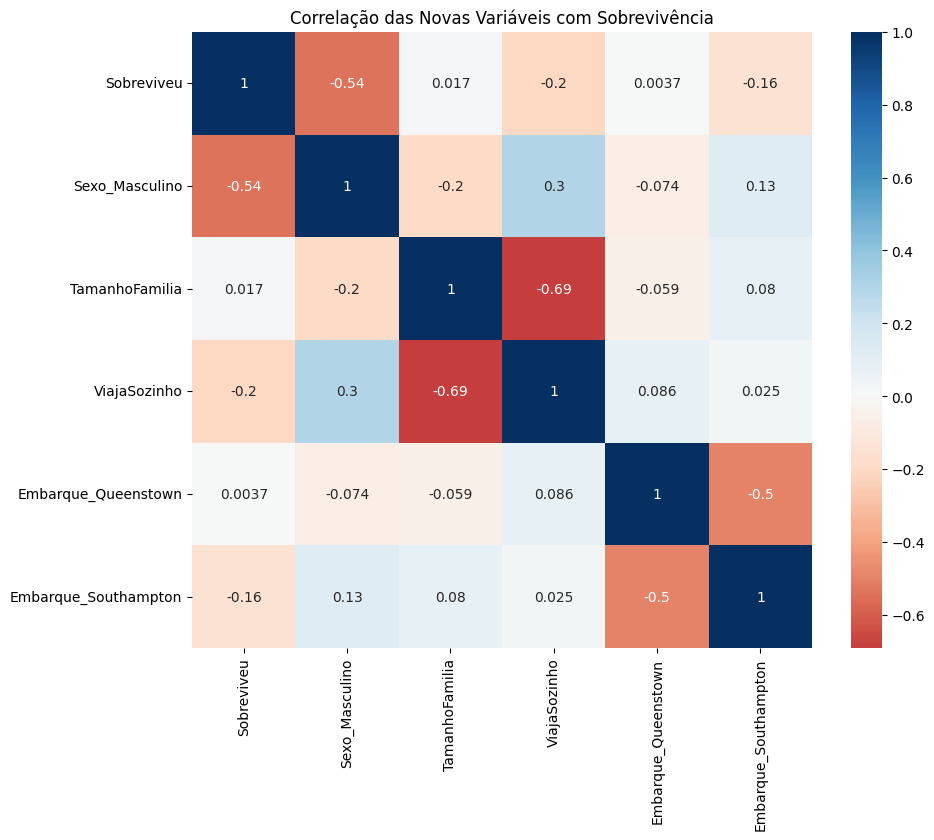

/tmp/ipykernel_4621/749087585.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Título', y='Sobreviveu', data=df, palette='magma')


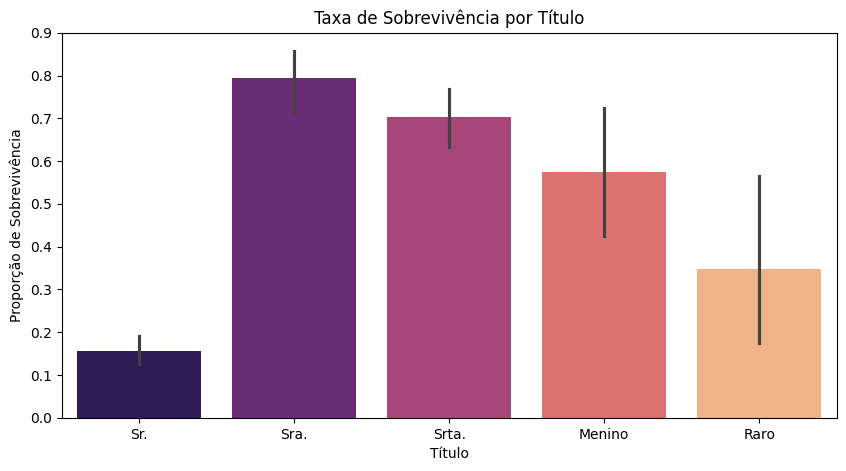

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisando a correlação das novas features
novas_cols = ['Sobreviveu', 'Sexo_Masculino', 'TamanhoFamilia', 'ViajaSozinho', 'Embarque_Queenstown', 'Embarque_Southampton']
plt.figure(figsize=(10, 8))
sns.heatmap(df[novas_cols].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Correlação das Novas Variáveis com Sobrevivência')
plt.show()

# Visualizando a sobrevivência por Título
plt.figure(figsize=(10, 5))
sns.barplot(x='Título', y='Sobreviveu', data=df, palette='magma')
plt.title('Taxa de Sobrevivência por Título')
plt.ylabel('Proporção de Sobrevivência')
plt.show()

### Melhoria Final: Tratamento de Valores Ausentes (Idade)
Como identificamos na inspeção inicial, a coluna 'Idade' possui valores nulos. Vamos preenchê-los de forma inteligente usando a mediana de cada grupo de 'Título'.

In [14]:
# Preenchendo valores nulos da Idade com a mediana baseada no Título
df['Idade'] = df['Idade'].fillna(df.groupby('Título')['Idade'].transform('median'))

# Verificando se ainda restam nulos
print(f"Valores nulos em Idade após imputação: {df['Idade'].isnull().sum()}")

# Salvando a versão final atualizada
df.to_csv('titanic_final_pt_v2.csv', index=False)
print("Dataset atualizado salvo como 'titanic_final_pt_v2.csv'")

Valores nulos em Idade após imputação: 0
Dataset atualizado salvo como 'titanic_final_pt_v2.csv'


### 🌟 Visualização Aprimorada
Nesta seção, vamos gerar versões mais legíveis das análises anteriores, focando em clareza para apresentações.

Taxa de Sobrevivência (%) - Visão Executiva:


Sexo,Feminino,Masculino
Classe,,
1,96.8%,36.9%
2,92.1%,15.7%
3,50.0%,13.5%


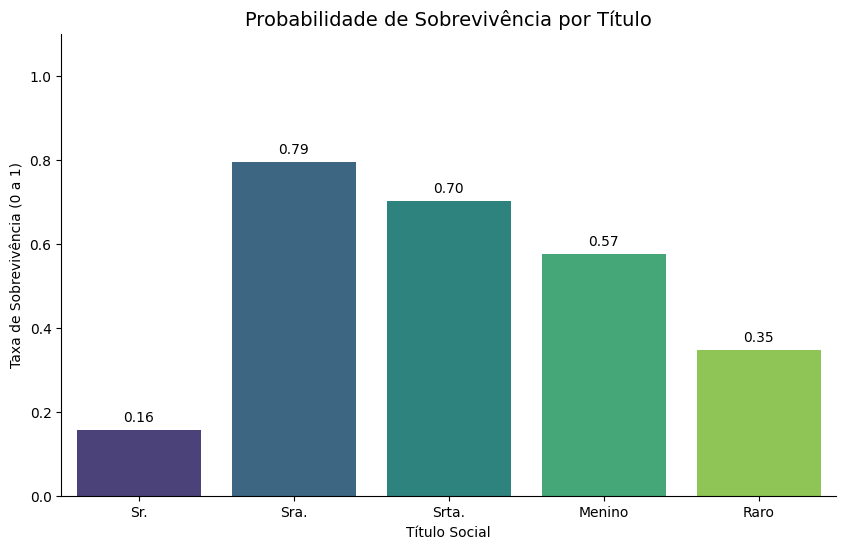

In [15]:
import warnings
warnings.filterwarnings('ignore') # Limpa avisos estéticos

# 1. Tabela Estilizada: Sobrevivência por Classe e Sexo
print("Taxa de Sobrevivência (%) - Visão Executiva:")
pivot_styled = df.pivot_table(index='Classe', columns='Sexo', values='Sobreviveu', aggfunc='mean') * 100
display(pivot_styled.style.background_gradient(cmap='Greens').format("{:.1f}%"))

# 2. Gráfico de Barras com Rótulos de Dados
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Título', y='Sobreviveu', data=df, palette='viridis', ci=None)

# Adicionando os números em cima das barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Probabilidade de Sobrevivência por Título', fontsize=14)
plt.ylabel('Taxa de Sobrevivência (0 a 1)')
plt.xlabel('Título Social')
plt.ylim(0, 1.1) # Espaço para o texto
sns.despine() # Remove bordas desnecessárias
plt.show()

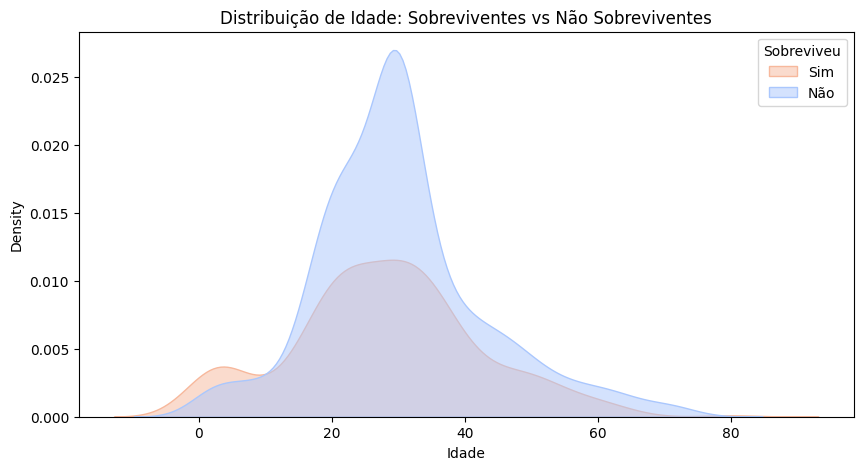

In [16]:
# 3. Distribuição de Idade por Sobrevivência (KDE Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Idade', hue='Sobreviveu', fill=True, palette='coolwarm', alpha=0.5)
plt.title('Distribuição de Idade: Sobreviventes vs Não Sobreviventes')
plt.legend(title='Sobreviveu', labels=['Sim', 'Não'])
plt.show()